# Detecção de Fraude em Cartão de Crédito — Classificação Extremamente Desbalanceada

**Objetivo:** identificar transações fraudulentas de cartão de crédito entre 284.807 transações
reais (48h, cartões europeus) — só **492 são fraude (0,17%)**, o desbalanceamento mais extremo
do portfólio (o projeto de risco de crédito tinha 6,6%). Esse nível de desbalanceamento exige
técnicas que os outros projetos de classificação não precisaram: balanceamento de classe e
curva Precision-Recall no lugar da ROC.

**Dataset:** [Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/mlg-ulb/creditcardfraud)
— `Time`, `Amount` e 28 variáveis anonimizadas via PCA (`V1`...`V28`, por confidencialidade dos
dados reais dos cartões) + `Class` (1 = fraude).

**Por que as variáveis são anônimas:** diferente do projeto de risco de crédito, aqui não dá pra
calcular Odds Ratios com significado de negócio (não sei o que é `V14`) — o foco desse projeto é
outro: robustez em desbalanceamento extremo, não interpretabilidade.

## 1. Importação e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Visão geral e limpeza

In [2]:
print(data.shape)
print(f"\nValores nulos: {data.isnull().sum().sum()}")
print(f"Duplicatas: {data.duplicated().sum()}")

data = data.drop_duplicates().reset_index(drop=True)
print(f"\nShape após remover duplicatas: {data.shape}")

(284807, 31)

Valores nulos: 0
Duplicatas: 1081

Shape após remover duplicatas: (283726, 31)


## 3. Distribuição do target

O desbalanceamento mais extremo do portfólio — vale ver o tamanho real do problema antes de
seguir.

       contagem  proporção
Class                     
0        283253    0.99833
1           473    0.00167


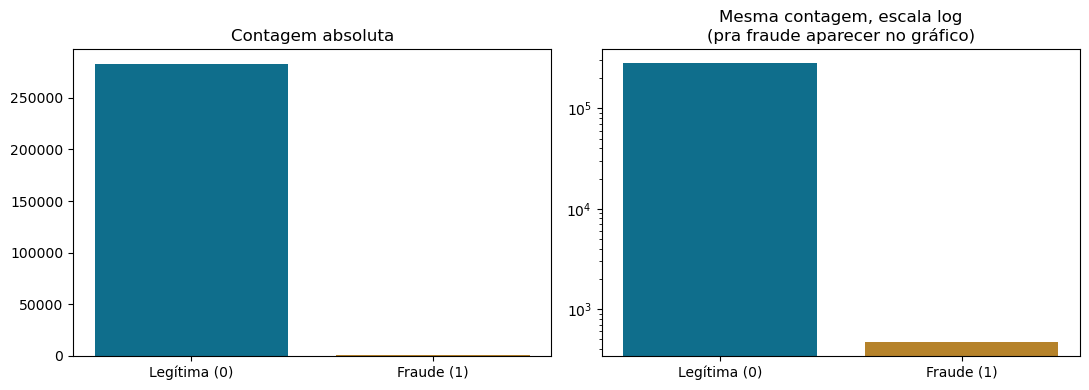

In [3]:
contagem = data['Class'].value_counts()
proporcao = data['Class'].value_counts(normalize=True)
print(pd.DataFrame({'contagem': contagem, 'proporção': proporcao.round(5)}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(['Legítima (0)', 'Fraude (1)'], contagem.values, color=['#0f6e8c', '#b5822a'])
axes[0].set_title('Contagem absoluta')

axes[1].bar(['Legítima (0)', 'Fraude (1)'], contagem.values, color=['#0f6e8c', '#b5822a'])
axes[1].set_yscale('log')
axes[1].set_title('Mesma contagem, escala log\n(pra fraude aparecer no gráfico)')

plt.tight_layout()
plt.show()

## 4. `Amount` e `Time` por classe

As únicas duas variáveis com significado de negócio direto (as outras são PCA anônimo) — vale
ver se fraude se comporta diferente nelas.

Amount por classe:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


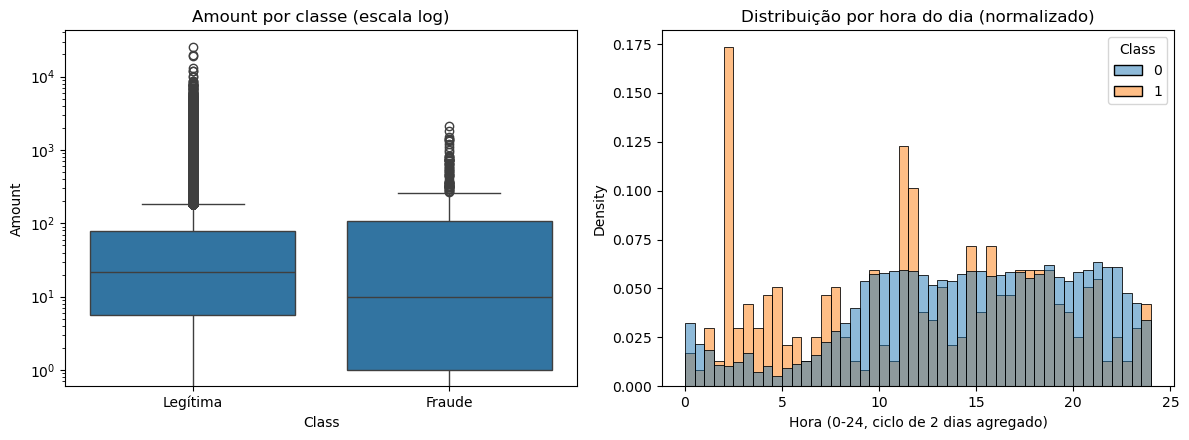

In [4]:
print("Amount por classe:")
print(data.groupby('Class')['Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=data, x='Class', y='Amount', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Legítima', 'Fraude'])
axes[0].set_title('Amount por classe (escala log)')

data['hora'] = (data['Time'] % (24 * 3600)) / 3600
sns.histplot(data=data, x='hora', hue='Class', stat='density', common_norm=False, bins=48, ax=axes[1])
axes[1].set_title('Distribuição por hora do dia (normalizado)')
axes[1].set_xlabel('Hora (0-24, ciclo de 2 dias agregado)')

plt.tight_layout()
plt.show()

## 5. Preparação dos dados

`V1`-`V28` já vêm padronizadas (saída de PCA). `Amount` e `Time` não — padronizo essas duas pra
ficarem na mesma escala. Split com `stratify` é obrigatório aqui: com 0,17% de positivos, um
split aleatório sem estratificar corre risco real de deixar poucas (ou nenhuma) fraude no teste.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data['Amount_scaled'] = StandardScaler().fit_transform(data[['Amount']])
data['Time_scaled'] = StandardScaler().fit_transform(data[['Time']])

features = [c for c in data.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']
X = data[features]
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Fraudes no treino: {y_train.sum()} ({y_train.mean():.4%}) | Fraudes no teste: {y_test.sum()} ({y_test.mean():.4%})")

Treino: (226980, 30) | Teste: (56746, 30)
Fraudes no treino: 378 (0.1665%) | Fraudes no teste: 95 (0.1674%)


## 6. Modelo baseline (sem tratar o desbalanceamento)

Regressão logística "crua", sem nenhuma técnica de balanceamento — serve de ponto de partida
pra medir o quanto as próximas técnicas realmente ajudam.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

modelo_base = LogisticRegression(max_iter=1000, random_state=42)
modelo_base.fit(X_train, y_train)

proba_base = modelo_base.predict_proba(X_test)[:, 1]
pred_base = modelo_base.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, pred_base):.4%}")
print(f"Precisão: {precision_score(y_test, pred_base):.3f}")
print(f"Recall: {recall_score(y_test, pred_base):.3f}")
print(f"F1: {f1_score(y_test, pred_base):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, proba_base):.4f}")
print(f"AUC-PR (average precision): {average_precision_score(y_test, proba_base):.4f}")

Acurácia: 99.9137%
Precisão: 0.848
Recall: 0.589
F1: 0.696
AUC-ROC: 0.9584
AUC-PR (average precision): 0.6935


## 7. Por que curva Precision-Recall, não ROC, nesse caso

Com 99,83% de classe negativa, a taxa de falsos positivos (eixo da ROC) fica minúscula quase
sempre — mesmo um modelo capengo consegue AUC-ROC alta só porque tem 56 mil transações legítimas
pra "diluir" qualquer engano. A curva Precision-Recall não usa a classe negativa no
denominador da mesma forma — ela mostra o trade-off real que interessa aqui: de cada alerta de
fraude que o modelo dispara, quantos são fraude de verdade (precisão) e quantas fraudes reais o
modelo pega (recall).

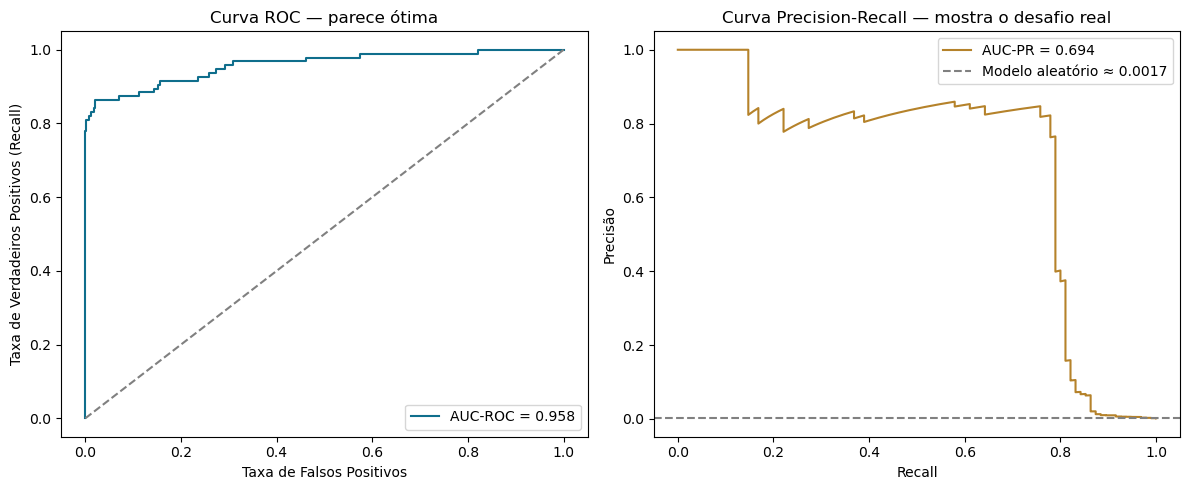

In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, proba_base)
prec, rec, _ = precision_recall_curve(y_test, proba_base)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='#0f6e8c', label=f'AUC-ROC = {roc_auc_score(y_test, proba_base):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[0].set_title('Curva ROC — parece ótima')
axes[0].legend()

axes[1].plot(rec, prec, color='#b5822a', label=f'AUC-PR = {average_precision_score(y_test, proba_base):.3f}')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Modelo aleatório ≈ {y_test.mean():.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall — mostra o desafio real')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Técnicas de balanceamento

Duas abordagens diferentes pra lidar com 0,17% de positivos:

- **`class_weight='balanced'`**: não mexe nos dados — faz o modelo "prestar mais atenção" nos
  erros da classe minoritária durante o treino, ponderando o erro de cada classe pelo inverso da
  sua frequência.
- **SMOTE**: gera exemplos sintéticos da classe minoritária (interpolando entre fraudes
  existentes) só no conjunto de treino, pra equilibrar as classes antes de treinar.

In [8]:
from imblearn.over_sampling import SMOTE

# class_weight='balanced'
modelo_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_cw.fit(X_train, y_train)
proba_cw = modelo_cw.predict_proba(X_test)[:, 1]

# SMOTE (só no treino!)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Treino original: {len(y_train)} linhas ({y_train.mean():.4%} fraude)")
print(f"Treino com SMOTE: {len(y_train_sm)} linhas ({y_train_sm.mean():.2%} fraude)")

modelo_smote = LogisticRegression(max_iter=1000, random_state=42)
modelo_smote.fit(X_train_sm, y_train_sm)
proba_smote = modelo_smote.predict_proba(X_test)[:, 1]

Treino original: 226980 linhas (0.1665% fraude)
Treino com SMOTE: 453204 linhas (50.00% fraude)


## 9. XGBoost com `scale_pos_weight`

Terceira abordagem de balanceamento, dessa vez com um modelo não-linear — `scale_pos_weight`
funciona como o `class_weight`, mas nativo do XGBoost.

In [9]:
from xgboost import XGBClassifier

peso = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {peso:.1f}")

modelo_xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=peso, eval_metric='aucpr', random_state=42
)
modelo_xgb.fit(X_train, y_train)
proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

scale_pos_weight: 599.5


## 10. Comparação de todos os modelos

In [10]:
modelos_proba = {
    'Baseline (sem balancear)': proba_base,
    'class_weight=balanced': proba_cw,
    'SMOTE': proba_smote,
    'XGBoost (scale_pos_weight)': proba_xgb,
}

linhas = []
for nome, proba in modelos_proba.items():
    pred = (proba >= 0.5).astype(int)
    linhas.append({
        'Modelo': nome,
        'Precisão': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, proba),
        'AUC-PR': average_precision_score(y_test, proba),
    })

comparacao = pd.DataFrame(linhas).round(4)
comparacao

,Modelo,Precisão,Recall,F1,AUC-ROC,AUC-PR
0,Baseline (sem balancear),0.8485,0.5895,0.6957,0.9584,0.6935
1,class_weight=balanced,0.0561,0.8737,0.1055,0.9658,0.6720
2,SMOTE,0.0531,0.8737,0.1002,0.9619,0.6768
3,XGBoost (scale_pos_weight),0.5969,0.8105,0.6875,0.9691,0.7958


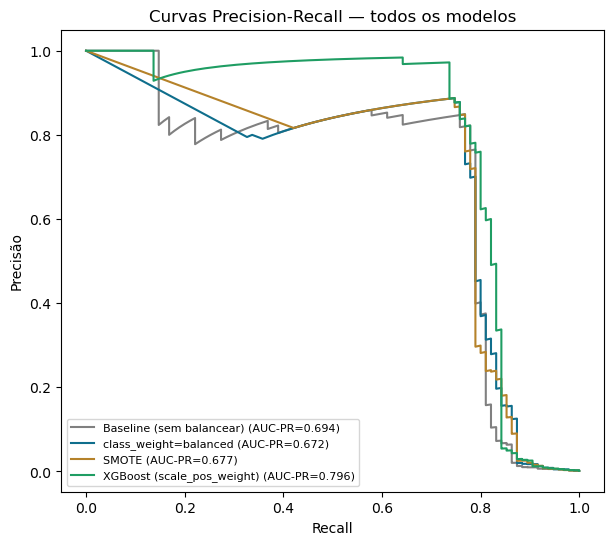

In [11]:
plt.figure(figsize=(7, 6))
cores = {'Baseline (sem balancear)': 'gray', 'class_weight=balanced': '#0f6e8c',
         'SMOTE': '#b5822a', 'XGBoost (scale_pos_weight)': '#1f9d63'}

for nome, proba in modelos_proba.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f'{nome} (AUC-PR={ap:.3f})', color=cores[nome])

plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curvas Precision-Recall — todos os modelos')
plt.legend(fontsize=8)
plt.show()

## 11. Achado honesto: balancear a classe não significa "pode manter o limiar em 0,5"

Olhando a tabela da seção 10: `class_weight=balanced` e `SMOTE` fizeram o recall saltar pra
87,4% — ótimo, capturam quase toda fraude. Mas a precisão **desabou para ~5,5%** — ou seja, de
cada 100 alertas de fraude que esses modelos disparam, **95 são falso alarme**. Isso não é bug:
balancear a classe desloca a fronteira de decisão de forma tão agressiva que, no limiar padrão
de 0,5, o modelo passa a "gritar fraude" com muita facilidade.

**A lição:** balanceamento de classe e ajuste de limiar resolvem problemas diferentes — um não
substitui o outro. Aplicar `class_weight='balanced'` e manter o limiar em 0,5 sem ajustar de
novo é um erro comum, e os números acima mostram exatamente o tamanho do estrago que isso causa
na prática.

**Pelo AUC-PR** (que não depende de limiar), o **XGBoost com `scale_pos_weight`** é o modelo
mais forte (0,796, contra 0,672-0,694 dos demais) — é ele que eu levo pro ajuste de limiar a
seguir.

## 12. Ajuste de limiar no XGBoost

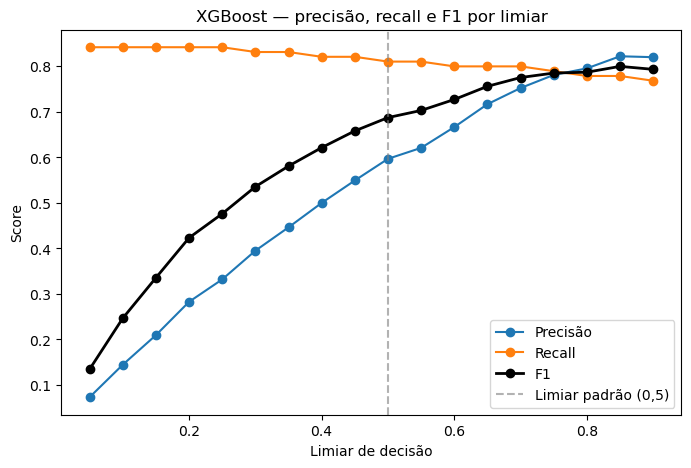

Melhor limiar por F1: 0.85 (precisão=0.822, recall=0.779, F1=0.800)


In [12]:
thresholds_teste = np.arange(0.05, 0.95, 0.05)
resultados_thr = []
for t in thresholds_teste:
    pred_t = (proba_xgb >= t).astype(int)
    resultados_thr.append({
        'threshold': round(t, 2),
        'precisao': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })

df_thr = pd.DataFrame(resultados_thr)

plt.figure(figsize=(8, 5))
plt.plot(df_thr['threshold'], df_thr['precisao'], marker='o', label='Precisão')
plt.plot(df_thr['threshold'], df_thr['recall'], marker='o', label='Recall')
plt.plot(df_thr['threshold'], df_thr['f1'], marker='o', label='F1', color='black', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Limiar padrão (0,5)')
plt.xlabel('Limiar de decisão')
plt.ylabel('Score')
plt.title('XGBoost — precisão, recall e F1 por limiar')
plt.legend()
plt.show()

melhor = df_thr.loc[df_thr['f1'].idxmax()]
print(f"Melhor limiar por F1: {melhor['threshold']:.2f} (precisão={melhor['precisao']:.3f}, recall={melhor['recall']:.3f}, F1={melhor['f1']:.3f})")

## 13. Matriz de confusão no limiar ajustado

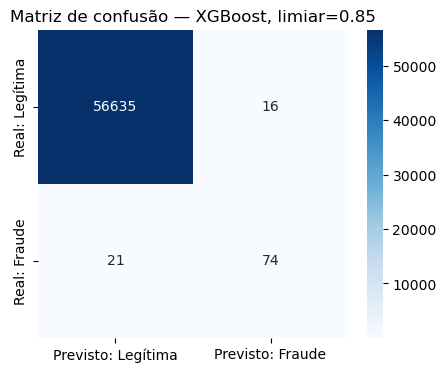

Comparando com o limiar padrão (0,5):
  0,50 -> precisão=0.597, recall=0.811, F1=0.688
  0.85 -> precisão=0.822, recall=0.779, F1=0.800


In [13]:
limiar_final = melhor['threshold']
pred_final = (proba_xgb >= limiar_final).astype(int)

cm = confusion_matrix(y_test, pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Legítima', 'Previsto: Fraude'],
            yticklabels=['Real: Legítima', 'Real: Fraude'])
plt.title(f'Matriz de confusão — XGBoost, limiar={limiar_final:.2f}')
plt.show()

print(f"Comparando com o limiar padrão (0,5):")
pred_05 = (proba_xgb >= 0.5).astype(int)
print(f"  0,50 -> precisão={precision_score(y_test, pred_05):.3f}, recall={recall_score(y_test, pred_05):.3f}, F1={f1_score(y_test, pred_05):.3f}")
print(f"  {limiar_final:.2f} -> precisão={precision_score(y_test, pred_final):.3f}, recall={recall_score(y_test, pred_final):.3f}, F1={f1_score(y_test, pred_final):.3f}")

## 14. Conclusões

**Resultado final:** o XGBoost com `scale_pos_weight`, ajustando o limiar de 0,5 para **0,85**,
melhorou a precisão de **59,7% para 82,2%** — reduzindo bastante os falsos alarmes — mantendo
recall alto (77,9%, contra 81,1% no limiar padrão). F1 subiu de 0,688 para **0,800**. Diferente
do projeto de risco de crédito (onde baixar o limiar melhorou o recall à custa da acurácia),
aqui **subir** o limiar melhorou o equilíbrio geral — cada dataset pede um ajuste na direção
certa, não existe "sempre baixe o limiar" ou "sempre suba".

**Por que balanceamento de classe sozinho não bastava:** `class_weight='balanced'` e `SMOTE`
pareciam ótimos pelo recall (87,4%), mas a precisão desabou pra ~5,5% no limiar padrão — 95% dos
alertas seriam falso positivo. Isso mostra na prática por que threshold e balanceamento são
decisões independentes: balancear muda o modelo, mas não escolhe o limiar por você.

**Por que Precision-Recall, não ROC, guiou as decisões aqui:** com 99,83% de classe negativa, a
AUC-ROC de todos os modelos ficou artificialmente alta (0,958 a 0,969) — pouco útil pra
diferenciar entre eles. O AUC-PR mostrou uma diferença real: XGBoost (0,796) claramente à frente
dos demais (0,672-0,694) — foi essa métrica, não a ROC, que decidiu qual modelo usar.

**Comparação com o portfólio:** esse é o desbalanceamento mais extremo (0,17% vs 6,6% do projeto
de crédito), e por isso foi o único que exigiu técnica de balanceamento explícita
(`class_weight`/SMOTE/`scale_pos_weight`) — nos outros projetos de classificação, ajustar só o
limiar já bastava.

**Próximos passos possíveis:**
- Testar undersampling (reduzir a classe majoritária) como quarta técnica de balanceamento.
- Validação cruzada estratificada, em vez de um único split, pra confirmar que o limiar de 0,85
  generaliza.
- Custo assimétrico explícito (ex: custo de um falso negativo = valor médio da transação
  fraudulenta) em vez de otimizar F1, que trata todo erro como igualmente caro.

## 15. Insights

"Esse foi o desbalanceamento mais extremo do portfólio — 0,17% de fraude, bem além do projeto de
crédito. Testei três formas de lidar com isso: `class_weight`, SMOTE e `scale_pos_weight` no
XGBoost. A parte mais reveladora foi perceber que balancear a classe não resolve sozinho — com
`class_weight='balanced'` no limiar padrão, a precisão caiu pra 5%, porque balancear muda o
modelo, mas não escolhe o limiar de decisão por você. Troquei a métrica de avaliação de ROC para
Precision-Recall, porque com 99,8% de classe negativa a ROC fica artificialmente boa e não
diferencia os modelos direito. No fim, ajustando o limiar do XGBoost pra 0,85 em vez de 0,5, a
precisão subiu de 60% para 82% sem perder muito recall. Foi o projeto que mais me obrigou a
entender a fundo a diferença entre balancear dado e ajustar decisão."